# Математическая статистика для анализа больших данных.
## Задание 13
### Методы семплирования

**Правила:**


* Выполненную работу нужно отправить [телеграм-боту](https://t.me/stats_bd_bot).
* Дедлайн указан в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно ноутбук в формате `ipynb`.
* Если вы прикрепляете фотографии к ноутбуку, убедитесь, что они "вшиты" туда, а не ссылаются на локальный путь
* Решения, размещенные на каких-либо интернет-ресурсах не принимаются. Публикация решения может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as sps

import matplotlib.pyplot as plt
import seaborn as sns

import pymc as pm

import warnings

sns.set(palette='Set2')
warnings.filterwarnings('ignore')

%matplotlib inline

## Задача 1 (6 баллов)

Рассмотрим почасовые данные о посещаемости сайта Физтех.Статистики и вики-страниц за период с 1 сентября до 9 октября 2021. Данные следует взять из задания 10. Предположим, что количество посетителей за час имеет пуассоновское распределение с параметром $\alpha_j\beta_k$, где $\beta_k$ &mdash; коэффициент активности пользователей за час $k \in \{0, 1, ..., 23\}$, а $\alpha_j$ &mdash; степень востребованности ресурса $j \in \{0, 1\}$.

Пусть $\beta_k$ имеет априорное распределение $U[0, 2]$, а $\alpha_j$ &mdash; априорное распределение гамма, у которого среднее равно 5.

Постройте модель с помощью библиотеки PyMC, найдите апостериорные распределения всех параметров. Визуализируйте зависимость $\beta_k$ от $k$, используя характеристики апостериорных распределений. Сравните апостериорные распределения $\alpha_0$ и $\alpha_1$.

In [ ]:
data = pd.read_excel('data_task10.xlsx')

In [41]:
data['ym:s:dateTimeUTC'] = pd.to_datetime(data['ym:s:dateTimeUTC'])
data['hour'] = data['ym:s:dateTimeUTC'].dt.hour
# Если эндпоинт содержит домен физтех статистики, добавляем его в ресурс 0, остальное(вики страницы) в ресурс 1
data['resource'] = data['ym:s:endURL'].apply(
    lambda x: 0 if ('miptstats' in x or 'mipt-stats' in x) else 1
)

data = data[data['resource'] != -1]

hourly_visits = data.groupby(['resource', 'hour']).size().reset_index(name='visits')

visits_pivot = hourly_visits.pivot(index='hour', columns='resource', values='visits').fillna(0)
visits_pivot.columns = ['resource_0', 'resource_1']
visits_pivot.reset_index(inplace=True)

print(visits_pivot.head())

   hour  resource_0  resource_1
0     0        5586         757
1     1        3814         500
2     2        2323         311
3     3        1539         212
4     4        1265         125


In [42]:
resource_0 = visits_pivot['resource_0'].values
resource_1 = visits_pivot['resource_1'].values
hours = visits_pivot['hour'].values

with pm.Model() as model:
    beta = pm.Uniform('beta', lower=0, upper=2, shape=len(hours))

    alpha_0 = pm.Gamma('alpha_0', alpha=5, beta=1)
    alpha_1 = pm.Gamma('alpha_1', alpha=5, beta=1)

    mu_0 = alpha_0 * beta
    mu_1 = alpha_1 * beta

    X_0 = pm.Poisson('X_0', mu=mu_0, observed=resource_0)
    X_1 = pm.Poisson('X_1', mu=mu_1, observed=resource_1)

    trace = pm.sample(2000, tune=500, cores=4)

Output()

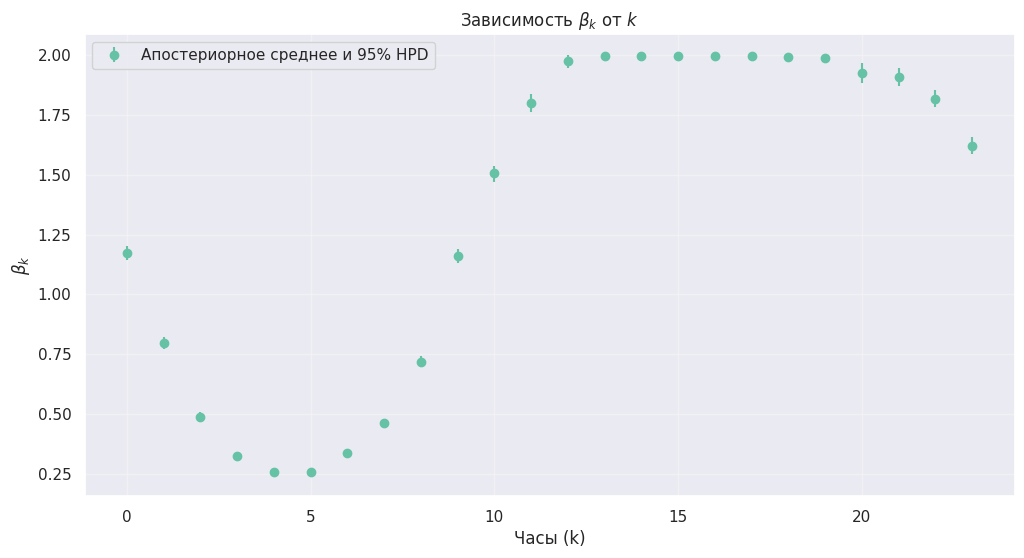

In [43]:
beta_samples = trace.posterior['beta'].values
beta_mean = beta_samples.mean(axis=(0, 1))
beta_hpd = pm.hdi(beta_samples, hdi_prob=0.95)

plt.figure(figsize=(12, 6))
plt.errorbar(hours, beta_mean,
             yerr=[beta_mean - beta_hpd[:, 0], beta_hpd[:, 1] - beta_mean],
             fmt='o', label='Апостериорное среднее и 95% HPD')
plt.title('Зависимость $\\beta_k$ от $k$')
plt.xlabel('Часы (k)')
plt.ylabel('$\\beta_k$')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


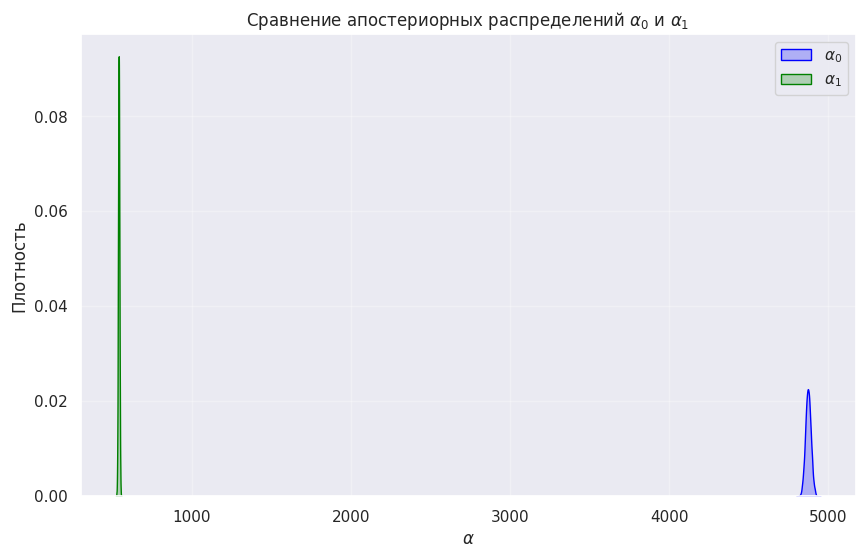

In [44]:
alpha_0_samples = trace.posterior['alpha_0'].values.flatten()
alpha_1_samples = trace.posterior['alpha_1'].values.flatten()

plt.figure(figsize=(10, 6))
sns.kdeplot(alpha_0_samples, label='$\\alpha_0$', color='blue', fill=True)
sns.kdeplot(alpha_1_samples, label='$\\alpha_1$', color='green', fill=True)
plt.title('Сравнение апостериорных распределений $\\alpha_0$ и $\\alpha_1$')
plt.xlabel('$\\alpha$')
plt.ylabel('Плотность')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [46]:
print(visits_pivot.mean())


hour            11.500000
resource_0    6798.041667
resource_1     752.791667
dtype: float64


**Вывод**: На графике представлены апостериорные распределения параметров $\alpha_0$ и $\alpha_1$, которые отражают степень востребованности ресурсов.Видно, что распределение $\alpha_0$, соответствующее ресурсу "Физтех.Статистика", сосредоточено около значения $5000$, что говорит о его высокой популярности. Напротив, распределение $\alpha_1$, соответствующее другому ресурсу, сосредоточено около значительно меньшего значения, что свидетельствует о его низкой востребованности. Средние значения числа посещений подтверждают этот вывод: для ресурса 0 среднее составляет $6798.04$ посещений в час, тогда как для ресурса 1 всего $752.79$. Таким образом, апостериорные оценки демонстрируют значительный разрыв в популярности между ресурсами. Ресурс "Физтех.Статистика" явно доминирует в пользовательском интересе.


## Задача 2 (7 баллов)

Дано распределение на $\mathbb{R}^2$ с плотностью
$$p(x, y) = c\:\frac{\left|\sin(x+y)\right|\:\exp\left(-\left.|x|\right/10+\cos y\right)}{1+\left.|xy|\right/10},$$

где $c\in \mathbb{R}_+$ &mdash; некоторое число.

Сгенерируйте из него выборку размера $n=2000$ с помощью
* метода Rejection sampling,
* схемы Метрополиса-Хастингса.

В каждом случае нарисуйте ядерную оценку плотности полученной выборки и сравните ее с истинной плотностью.

<font color="red"><b>Замечания:</b></font>
    
1. Вместо $\mathbb{R}^2$ можно рассматривать только квадрат $[-10, 10]^2$.
2. Учтите, что схема Метрополиса-Хастингса требует настройки цепи на начальных итерациях, то есть около 1000 первых итераций необходимо отбросить. Кроме того, если требуется сгенерировать именно выборку, в которой элементы независимы, из полученной траектории стоит брать каждый $k$-й элемент, где $k$ хотя бы 10.
3. При сравнении методов учтите, что метод Rejection sampling может отвергать точки, в то время как в схеме Метрополиса-Хастингса точка добавляется на каждой итерации (повторяется или берется новая).

Посчитайте для данного распределения математическое ожидание и матрицу ковариаций.

Rejection Sampling: Mean = [ 0.04715108 -0.0075595 ]
Rejection Sampling: Covariance Matrix = [[16.96676325 -0.52558872]
 [-0.52558872 21.42263088]]
Metropolis-Hastings: Mean = [-0.12942649 -0.69813625]
Metropolis-Hastings: Covariance Matrix = [[16.01707105  1.20288703]
 [ 1.20288703 21.4243356 ]]


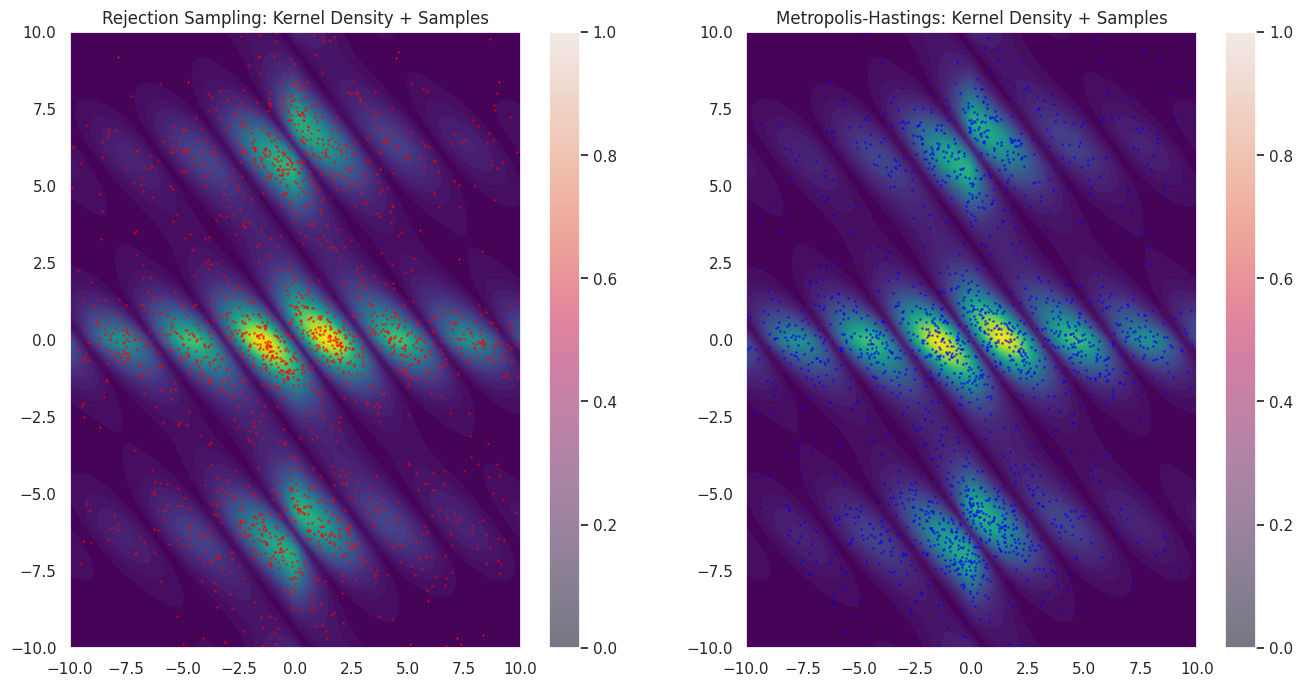

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform, norm
from scipy.stats import multivariate_normal
from scipy.integrate import dblquad

def p(x, y):
    return np.abs(np.sin(x + y)) * np.exp(-np.abs(x) / 10 + np.cos(y)) / (1 + np.abs(x * y) / 10)

def rejection_sampling(n, bounds=(-10, 10)):
    samples = []
    x_min, x_max = bounds
    y_min, y_max = bounds
    M = 5
    while len(samples) < n:
        x = np.random.uniform(x_min, x_max)
        y = np.random.uniform(y_min, y_max)
        u = np.random.uniform(0, M)
        if u < p(x, y):
            samples.append([x, y])
    return np.array(samples)

def metropolis_hastings(n, proposal_std=1.0, bounds=(-10, 10)):
    x, y = 0, 0
    samples = []
    for _ in range(n * 10 + 1000):  # Burn-in + thinning
        x_new, y_new = np.random.normal(x, proposal_std), np.random.normal(y, proposal_std)
        if not (bounds[0] <= x_new <= bounds[1] and bounds[0] <= y_new <= bounds[1]):
            continue
        alpha = min(1, p(x_new, y_new) / p(x, y))
        if np.random.uniform(0, 1) < alpha:
            x, y = x_new, y_new
        samples.append([x, y])
    return np.array(samples[1000::10])

n = 2000
samples_rejection = rejection_sampling(n)
samples_mh = metropolis_hastings(n)

# Оценка матожидания и ковариационной матрицы
mean_rejection = np.mean(samples_rejection, axis=0)
cov_rejection = np.cov(samples_rejection.T)

mean_mh = np.mean(samples_mh, axis=0)
cov_mh = np.cov(samples_mh.T)

print("Rejection Sampling: Mean =", mean_rejection)
print("Rejection Sampling: Covariance Matrix =", cov_rejection)

print("Metropolis-Hastings: Mean =", mean_mh)
print("Metropolis-Hastings: Covariance Matrix =", cov_mh)

# Визуализация плотности
x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)
X, Y = np.meshgrid(x, y)
Z = p(X, Y)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.contourf(X, Y, Z, levels=50, cmap="viridis")
plt.scatter(samples_rejection[:, 0], samples_rejection[:, 1], color="red", alpha=0.5, s=1)
plt.title("Rejection Sampling: Kernel Density + Samples")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.contourf(X, Y, Z, levels=50, cmap="viridis")
plt.scatter(samples_mh[:, 0], samples_mh[:, 1], color="blue", alpha=0.5, s=1)
plt.title("Metropolis-Hastings: Kernel Density + Samples")
plt.colorbar()
plt.show()


На графиках представлены результаты генерации выборок из заданного распределения с использованием метода Rejection Sampling и схемы Метрополиса-Хастингса. Оба графика демонстрируют ядерные оценки плотности, наложенные на точки выборки.

Для метода Rejection Sampling среднее значение выборки составляет $[0.047, -0.008]$, а ковариационная матрица имеет вид:

$$
\begin{bmatrix}
16.97 & -0.53 \\
-0.53 & 21.42
\end{bmatrix}
$$

Этот метод обеспечивает равномерное покрытие областей с высокой плотностью распределения, но из-за частого отбрасывания точек может быть менее эффективным для сложных плотностей.

Метод Метрополиса-Хастингса показал среднее значение $[-0.129, -0.698]$ с ковариационной матрицей:

$$
\begin{bmatrix}
16.02 & 1.20 \\
1.20 & 21.42
\end{bmatrix}
$$

Данный метод генерирует точки быстрее, так как каждая итерация добавляет новую точку. Однако в этом случае наблюдаются более выраженные корреляции между переменными, что требует дополнительной настройки параметров цепи.

Оба метода хорошо передают структуру истинного распределения, включая характерные области высокой плотности. Rejection Sampling демонстрирует менее выраженные корреляции между переменными, в то время как схема Метрополиса-Хастингса показывает более сильные корреляции. Таким образом, выбор подходящего метода зависит от задачи: Rejection Sampling эффективен для более простых структур, тогда как схема Метрополиса-Хастингса лучше справляется со сложными распределениями, требуя при этом настройки параметров.
